In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from bilby import run_sampler
from bilby.core.prior import ConditionalPriorDict

from data import get_posteriors
from data import get_injections

from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

from models import log_powerlaw_redshift
from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth
from models import log_nid_iso_gauss_tilt
from models import log_iid_spin_mag_truncnorm

from likelihood import get_bilby_likelihood

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def cut_data(event_data, injections, snr=10, far=1):
    posteriors = event_data[0]
    event_snrs = event_data[2]
    event_fars = event_data[3]
    found = (event_fars < far) | (event_snrs > snr)
    posts = {k : v[found] for k, v in posteriors.items()}

    found = (injections['far'] < far) | (injections['snr'] > snr)
    injs = {k : v[found] for k, v in injections.items() if k not in ['time', 'total']}
    injs['total'] = injections['total']
    injs['time'] = injections['time']

    return posts, injs


def get_data(snr=10, far=1):
    event_data = get_posteriors(load=True)
    injections = get_injections(load=True)
    posteriors, injections = cut_data(event_data, injections, snr=snr, far=far)

    posteriors['mass_1'] = posteriors.pop('mass_1_source')

    injections['mass_1'] = injections.pop('mass_1_source')
    injections['total_generated'] = injections.pop('total')

    posteriors['log_prior'] = np.log(posteriors['prior'])
    injections['log_prior'] = np.log(injections['prior'])

    return posteriors, injections

In [3]:
post_snr10, injs_snr10 = get_data(snr=10, far=1)
post_snr15, injs_snr15 = get_data(snr=15, far=1e-5)

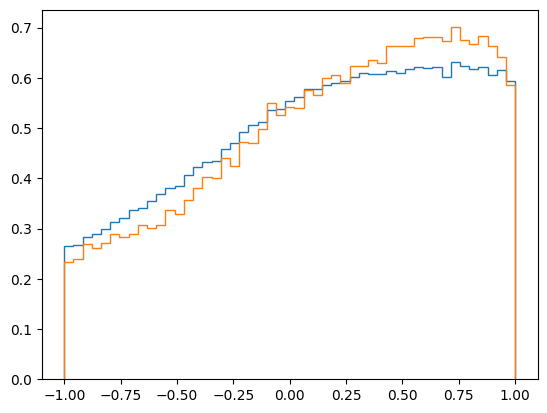

In [4]:
fig, ax = plt.subplots()
bins = np.linspace(-1, 1, 50)
ax.hist(post_snr10['cos_tilt_1'].flatten(), histtype='step', bins=bins, density=True);
ax.hist(post_snr15['cos_tilt_1'].flatten(), histtype='step', bins=bins, density=True);

In [15]:
def log_model(dataset, parameters):
    """ log-density of the population model """
    if 'lam_2' not in parameters:
        lam_2 = 1 - parameters['lam_1'] - parameters['lam_0']
    else:
        lam_2 = parameters['lam_2']

    log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
        dataset['mass_1'],
        alpha_1=parameters['alpha_1'],
        alpha_2=parameters['alpha_2'],
        mlow_1=parameters['mlow_1'],
        break_mass=parameters['break_mass'],
        delta_m_1=parameters['delta_m_1'],
        lam_fractions=(
            parameters['lam_0'], parameters['lam_1'], lam_2
        ),
        mpp_1=parameters['mpp_1'],
        sigpp_1=parameters['sigpp_1'],
        mpp_2=parameters['mpp_2'],
        sigpp_2=parameters['sigpp_2'],
        mmax=300.0,
        gaussian_mass_maximum=100.0
    )

    log_p_q = PowerlawPlusPeak_MassRatio(
        dataset,
        slope=parameters['beta'],
        minimum=parameters['mlow_1'],
        delta_m=parameters['delta_m_1']
    )

    log_p_z = log_powerlaw_redshift(dataset, parameters)

    log_p_chi = log_iid_spin_mag_truncnorm(dataset, parameters)

    log_p_tau = log_nid_iso_gauss_tilt(dataset, parameters)

    return log_p_m1 + log_p_q + log_p_z + log_p_chi + log_p_tau

In [16]:
priors = ConditionalPriorDict('./priors/lvk.prior')

In [17]:
maximum_variance = 1

def taper(v):
    """ its actually a hard cut! """
    return jnp.nan_to_num(-1e10 * (v >= maximum_variance), nan=0)

In [18]:
likelihood = get_bilby_likelihood(
    log_model,
    post_snr10,
    injs_snr10,
    taper=taper,
    rate=False
)

In [19]:
result = run_sampler(
    likelihood=likelihood,
    priors=priors,
    outdir='../../inference/cuts/snr10',
    label='test',
    sampler='dynesty',
    sample='acceptance-walk',
    naccept=5,
    nlive=100,
    # need enough live points to resolve w/in and w/o variance cut ...
)

12:35 bilby INFO    : Running for label 'test', output will be saved to '../../inference/cuts/snr10'
12:35 bilby INFO    : Analysis priors:
12:35 bilby INFO    : alpha_1=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
12:35 bilby INFO    : alpha_2=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
12:35 bilby INFO    : break_mass=Uniform(minimum=20, maximum=50, name=None, latex_label=None, unit=None, boundary=None)
12:35 bilby INFO    : mpp_1=Uniform(minimum=5, maximum=20, name=None, latex_label=None, unit=None, boundary=None)
12:35 bilby INFO    : sigpp_1=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
12:35 bilby INFO    : mpp_2=Uniform(minimum=25, maximum=60, name=None, latex_label=None, unit=None, boundary=None)
12:35 bilby INFO    : sigpp_2=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
12:35 bilby INFO    : delta_m_1=Uniform(minim

: 